## Best First Search

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

# This is a simple example of Best First Search (an informed search algorithm).
# Best First Search is a greedy algorithm that expands the node with the lowest
# heuristic value (estimated cost to the goal) first. It uses a priority queue
# to always pick the most promising node based on the heuristic.

# Define the graph using NetworkX. This creates an undirected graph.
# Nodes: A (start), B, C, D, E (goal)
# Edges represent possible moves between nodes.
G = nx.Graph()
G.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'D'), ('D', 'E')])

# Convert the NetworkX graph to a dictionary for easy access to neighbors during search.
graph = {node: list(G.neighbors(node)) for node in G.nodes()}

# Heuristic values: Estimated 'cost' from each node to the goal 'E'.
# These are arbitrary values for this example, representing something like
# straight-line distance in a hypothetical space. Lower is better.
heuristic = {'A': 1, 'B': 2, 'C': 3, 'D': 1, 'E': 0}

# Function to reconstruct the path from cameFrom dictionary.
# Starts from the goal and follows cameFrom backwards to the start.
# Returns the path as a list of nodes.
def reconstruct_path(cameFrom, start, goal):
    current = goal
    path = [current]
    while current != start:
        current = cameFrom[current]
        path.append(current)
    path.reverse()  # Reverse to get start to goal order.
    return path

# Function to perform Best First Search.
# Parameters: graph (dict of lists), start node, goal node, heuristic dict.
# It prints each node as it is expanded (traversed) step by step.
# Note: This is a simple implementation; it may not handle ties optimally or reconstruct the path,
# but it demonstrates the traversal order based on heuristics.
def best_first_search(graph, start, goal, heuristic):
    visited = set()  # Keep track of visited nodes to avoid cycles.
    pq = []  # Priority queue: stores (heuristic value, node). Uses heapq for min-heap.
    heapq.heappush(pq, (heuristic[start], start))  # Push start node.

    cameFrom = {}  # Dictionary to reconstruct path: cameFrom[node] = previous node.

    while pq:
        h, current = heapq.heappop(pq)  # Pop the node with the smallest heuristic.

        if current in visited:
            continue  # Skip if already visited (handles duplicate entries in pq)

        print(f"Expanding node: {current} (heuristic: {h})")  # Print the traversed node.

        if current == goal:
            path = reconstruct_path(cameFrom, start, goal)
            print(f"Best path: {' -> '.join(path)}")
            return True  # Found the goal.

        visited.add(current)  # Mark as visited.

        # Expand neighbors.
        for neighbor in graph[current]:
            if neighbor not in visited:
                if neighbor not in cameFrom:  # Set parent only on first discovery
                    cameFrom[neighbor] = current
                # Push neighbor with its heuristic. Note: Duplicates may occur if a node is reached multiple ways,
                # but for this simple example, we allow it (inefficient but correct for traversal demo).
                heapq.heappush(pq, (heuristic[neighbor], neighbor))

    print("Goal not reached.")
    return False

# Run the Best First Search from 'A' to 'E'.
best_first_search(graph, 'A', 'E', heuristic)

# Visualization using NetworkX and Matplotlib.
# This draws the graph with node positions for better visual understanding.
# Positions are arbitrary to space out the nodes nicely.
pos = {'A': (0,0), 'B': (1,1), 'C': (1,-1), 'D': (2,0), 'E': (3,0)}
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=16)
plt.title("Graph for Best First Search Example")
plt.show()

## A* Search

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

# This is a simple example of A* Search (an informed search algorithm).
# A* Search improves on Best First Search by considering both the path cost from the start (g)
# and the heuristic estimate to the goal (h), using f = g + h to prioritize nodes.
# It is complete and optimal if the heuristic is admissible (never overestimates) and consistent.
# This implementation uses a priority queue for the open set and tracks g-scores to update paths if better ones are found.
# We've added path reconstruction using a cameFrom dictionary to print the best path once the goal is reached.

# Define the graph using NetworkX. This creates an undirected graph with weighted edges.
# Nodes: A (start), B, C, D, E (goal)
# Edges with costs: A-B (cost 1), A-C (cost 1), B-D (cost 2), C-D (cost 1), D-E (cost 1)
G = nx.Graph()
G.add_weighted_edges_from([('A', 'B', 1), ('A', 'C', 1), ('B', 'D', 2), ('C', 'D', 1), ('D', 'E', 1)])

# Convert the NetworkX graph to a dictionary of dicts for easy access to neighbors and costs.
graph = {node: {nbr: data['weight'] for nbr, data in G[node].items()} for node in G.nodes()}

# Heuristic values: Estimated cost from each node to the goal 'E'.
# These are admissible (underestimate or equal true cost) for optimality in this example.
heuristic = {'A': 3, 'B': 2, 'C': 2, 'D': 1, 'E': 0}

# Function to reconstruct the path from cameFrom dictionary.
# Starts from the goal and follows cameFrom backwards to the start.
# Returns the path as a list of nodes.
def reconstruct_path(cameFrom, start, goal):
    current = goal
    path = [current]
    while current != start:
        current = cameFrom[current]
        path.append(current)
    path.reverse()  # Reverse to get start to goal order.
    return path

# Function to perform A* Search.
# Parameters: graph (dict of dicts with costs), start node, goal node, heuristic dict.
# It prints each node as it is expanded (traversed) step by step.
# Now includes path reconstruction and printing the best path if goal is reached.
def a_star_search(graph, start, goal, heuristic):
    gScore = {node: float('inf') for node in graph}  # Path cost from start to node.
    gScore[start] = 0
    fScore = {node: float('inf') for node in graph}  # Estimated total cost (g + h).
    fScore[start] = heuristic[start]

    cameFrom = {}  # Dictionary to reconstruct path: cameFrom[node] = previous node.

    pq = []  # Priority queue: stores (fScore, node). Uses heapq for min-heap.
    heapq.heappush(pq, (fScore[start], start))

    visited = set()  # Closed set: nodes already expanded.

    while pq:
        f, current = heapq.heappop(pq)  # Pop the node with the smallest f.
        print(f"Expanding node: {current} (f: {f}, g: {gScore[current]}, h: {heuristic[current]})")  # Print the traversed node.

        if current == goal:
            print("Goal reached!")
            path = reconstruct_path(cameFrom, start, goal)
            print(f"Best path: {' -> '.join(path)}")
            return True  # Found the goal.

        visited.add(current)  # Mark as expanded.

        # Expand neighbors.
        for neighbor, cost in graph[current].items():
            if neighbor in visited:
                continue  # Skip if already expanded (optimization for consistent heuristic).

            tentative_g = gScore[current] + cost  # Tentative path cost to neighbor.

            if tentative_g < gScore[neighbor]:  # Better path found.
                cameFrom[neighbor] = current  # Update predecessor.
                gScore[neighbor] = tentative_g
                fScore[neighbor] = tentative_g + heuristic[neighbor]
                # If neighbor not in pq, add it; else, it's already there (heapq doesn't support decrease key, so duplicates ok but inefficient).
                if neighbor not in [item[1] for item in pq]:  # Simple check to avoid too many duplicates.
                    heapq.heappush(pq, (fScore[neighbor], neighbor))

    print("Goal not reached.")
    return False

# Run the A* Search from 'A' to 'E'.
a_star_search(graph, 'A', 'E', heuristic)

# Visualization using NetworkX and Matplotlib.
# This draws the graph with edge labels for costs and node positions.
pos = {'A': (0,0), 'B': (1,1), 'C': (1,-1), 'D': (2,0), 'E': (3,0)}
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=16)
# Add edge labels for weights.
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Graph for A* Search Example")
plt.show()

## Minimax Algorithm

Starting Minimax from root A (Max):
Entering max child: B from A
Entering min child: D from B
Evaluating leaf node: D (value: 3)
Exiting min child: D from B with eval: 3
Entering min child: E from B
Evaluating leaf node: E (value: 5)
Exiting min child: E from B with eval: 5
Exiting max child: B from A with eval: 3
Entering max child: C from A
Entering min child: F from C
Evaluating leaf node: F (value: 2)
Exiting min child: F from C with eval: 2
Entering min child: G from C
Evaluating leaf node: G (value: 9)
Exiting min child: G from C with eval: 9
Exiting max child: C from A with eval: 2

Best value for maximizer: 3
Best path (principal variation): A -> B -> D -> D


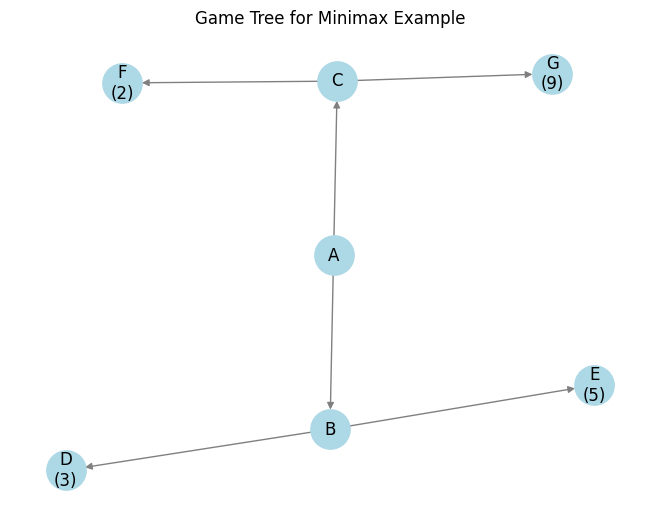

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# This is a simple example of the Minimax algorithm.
# Minimax is a recursive algorithm used in decision-making and game theory to find the optimal move for a player,
# assuming the opponent also plays optimally. It alternates between maximizing (for one player) and minimizing (for the opponent).
# In this example, we use a small game tree where:
# - Maximizing player starts at the root (wants to maximize the score).
# - Minimizing player responds (wants to minimize the score).
# - Leaf nodes have static values (e.g., game outcomes).
# The algorithm evaluates the tree depth-first, printing evaluations as it goes.
# It returns the best value and the principal variation path (best path assuming optimal play by both).

# Define the game tree structure as a dictionary of children.
# Root: A (Max)
# Level 1: B (Min), C (Min)
# Level 2: D=3, E=5 (from B); F=2, G=9 (from C)
children = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G']
}

# Leaf node values (scores; higher is better for maximizer).
values = {'D': 3, 'E': 5, 'F': 2, 'G': 9}

# Recursive Minimax function.
# Parameters: node (current node), maximizingPlayer (True for max, False for min).
# Returns: (best_value, best_path_from_here) where best_path_from_here is list of nodes to the leaf.
def minimax(node, maximizingPlayer):
    if node in values:  # Leaf node.
        print(f"Evaluating leaf node: {node} (value: {values[node]})")
        return values[node], [node]

    if maximizingPlayer:
        maxEval = float('-inf')
        best_path = []
        for child in children[node]:
            print(f"Entering max child: {child} from {node}")
            eval, path = minimax(child, False)
            print(f"Exiting max child: {child} from {node} with eval: {eval}")
            if eval > maxEval:
                maxEval = eval
                best_path = [child] + path
        return maxEval, best_path
    else:
        minEval = float('inf')
        best_path = []
        for child in children[node]:
            print(f"Entering min child: {child} from {node}")
            eval, path = minimax(child, True)
            print(f"Exiting min child: {child} from {node} with eval: {eval}")
            if eval < minEval:
                minEval = eval
                best_path = [child] + path
        return minEval, best_path

# Run Minimax from root 'A' (maximizing player).
print("Starting Minimax from root A (Max):")
best_value, best_path = minimax('A', True)
full_path = ['A'] + best_path
print(f"\nBest value for maximizer: {best_value}")
print(f"Best path (principal variation): {' -> '.join(full_path)}")

# Build the game tree as a NetworkX DiGraph for visualization.
G = nx.DiGraph()
for parent in children:
    for child in children[parent]:
        G.add_edge(parent, child)

# Node labels: include value for leaves.
labels = {node: f"{node}\n({values[node]})" if node in values else node for node in G.nodes()}

# Visualization using NetworkX and Matplotlib.
# Positions: hierarchical layout for tree structure.
pos = nx.spring_layout(G)  # Or use manual positions if preferred.
nx.draw(G, pos, with_labels=True, labels=labels, node_color='lightblue', edge_color='gray', node_size=800, font_size=12, arrows=True)
plt.title("Game Tree for Minimax Example")
plt.show()

## Alpha-Beta Pruning

Starting Alpha-Beta from root A (Max):
Entering max node: A (alpha: -inf, beta: inf)
  Exploring child: B from A
Entering min node: B (alpha: -inf, beta: inf)
  Exploring child: D from B
Evaluating leaf node: D (value: 6)
  Returned from D: val=6
  Exploring child: E from B
Evaluating leaf node: E (value: 1)
  Returned from E: val=1
Exiting min node: B with best: 1
  Returned from B: val=1
  Exploring child: C from A
Entering min node: C (alpha: 1, beta: inf)
  Exploring child: F from C
Evaluating leaf node: F (value: 2)
  Returned from F: val=2
  Exploring child: G from C
Evaluating leaf node: G (value: 9)
  Returned from G: val=9
Exiting min node: C with best: 2
  Returned from C: val=2
Exiting max node: A with best: 2

Best value for maximizer: 2
Best path (principal variation): A -> C -> F -> F


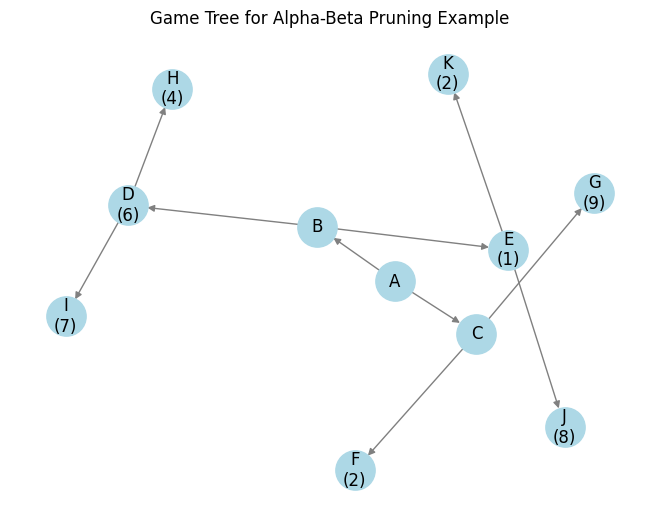

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# This is a simple example of the Alpha-Beta Pruning algorithm, an optimization of Minimax.
# Alpha-Beta Pruning reduces the number of nodes evaluated in the Minimax search tree by pruning branches
# that cannot influence the final decision. It maintains alpha (best value maximizer can guarantee) and
# beta (best value minimizer can guarantee) to skip unnecessary evaluations.
# In this example, we use the same small game tree as Minimax:
# - Maximizing player starts at the root (wants to maximize the score).
# - Minimizing player responds (wants to minimize the score).
# - Leaf nodes have static values (e.g., game outcomes).
# The algorithm evaluates the tree depth-first, printing evaluations and prunings as it goes.
# It returns the best value and the principal variation path (best path assuming optimal play by both).

# Define the game tree structure as a dictionary of children.
# Root: A (Max)
# Level 1: B (Min), C (Min)
# Level 2: D=3, E=5 (from B); F=2, G=9 (from C)
children = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': ['H', 'I'],
    'E': ['J', 'K']
}

# Leaf node values (scores; higher is better for maximizer).
values = {'D': 6, 'E': 1, 'F': 2, 'G': 9, 'H': 4, 'I': 7, 'J': 8, 'K': 2}

# Recursive Alpha-Beta function (Minimax with pruning).
# Parameters: node (current node), alpha, beta, maximizingPlayer (True for max, False for min).
# Returns: (best_value, best_path_from_here) where best_path_from_here is list of nodes to the leaf.
def alpha_beta(node, alpha, beta, maximizingPlayer):
    if node in values:  # Leaf node.
        print(f"Evaluating leaf node: {node} (value: {values[node]})")
        return values[node], [node]

    best_path = []
    if maximizingPlayer:
        best = float('-inf')
        print(f"Entering max node: {node} (alpha: {alpha}, beta: {beta})")
        for child in children[node]:
            print(f"  Exploring child: {child} from {node}")
            val, path = alpha_beta(child, alpha, beta, False)
            print(f"  Returned from {child}: val={val}")
            if val > best:
                best = val
                best_path = [child] + path
            alpha = max(alpha, best)
            if alpha >= beta:
                print(f"  Pruning remaining branches at {node} (alpha >= beta: {alpha} >= {beta})")
                break
        print(f"Exiting max node: {node} with best: {best}")
        return best, best_path
    else:
        best = float('inf')
        print(f"Entering min node: {node} (alpha: {alpha}, beta: {beta})")
        for child in children[node]:
            print(f"  Exploring child: {child} from {node}")
            val, path = alpha_beta(child, alpha, beta, True)
            print(f"  Returned from {child}: val={val}")
            if val < best:
                best = val
                best_path = [child] + path
            beta = min(beta, best)
            if alpha >= beta:
                print(f"  Pruning remaining branches at {node} (alpha >= beta: {alpha} >= {beta})")
                break
        print(f"Exiting min node: {node} with best: {best}")
        return best, best_path

# Run Alpha-Beta from root 'A' (maximizing player).
print("Starting Alpha-Beta from root A (Max):")
best_value, best_path = alpha_beta('A', float('-inf'), float('inf'), True)
full_path = ['A'] + best_path
print(f"\nBest value for maximizer: {best_value}")
print(f"Best path (principal variation): {' -> '.join(full_path)}")

# Build the game tree as a NetworkX DiGraph for visualization.
G = nx.DiGraph()
for parent in children:
    for child in children[parent]:
        G.add_edge(parent, child)

# Node labels: include value for leaves.
labels = {node: f"{node}\n({values[node]})" if node in values else node for node in G.nodes()}

# Visualization using NetworkX and Matplotlib.
# Positions: hierarchical layout for tree structure.
pos = nx.spring_layout(G)  # Or use manual positions if preferred.
nx.draw(G, pos, with_labels=True, labels=labels, node_color='lightblue', edge_color='gray', node_size=800, font_size=12, arrows=True)
plt.title("Game Tree for Alpha-Beta Pruning Example")
plt.show()